In [1]:
import torch
import ultralytics

print(f"Ultralytics version: {ultralytics.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

Ultralytics version: 8.4.33
CUDA available: True
Device: NVIDIA GeForce RTX 4090


In [2]:
%pip install tensorboard
%load_ext tensorboard
%tensorboard --logdir OD_OCR_Final/rtdetr_x_augmented_run


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import warnings
import os
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

from ultralytics import RTDETR

def train_model():
    model = RTDETR("rtdetr-x.pt")
    
    results = model.train(
        data="data.yaml",
        epochs=100,
        imgsz=1024,
        batch=4,                
        device=0,
        verbose=False,
        
        # --- ỔN ĐỊNH SỐ HỌC ---
        lr0=0.0001,             
        amp=False,              
        warmup_epochs=5.0,      
        
        # --- CHỐNG OVERFITTING ---
        patience=20,
        weight_decay=0.001,     
        dropout=0.1,
        
        # --- KHÓA 100% AUGMENTATION CỦA ULTRALYTICS ---
        fliplr=0.0,
        flipud=0.0,
        mosaic=0.0,
        mixup=0.0,
        degrees=0.0,
        erasing=0.0,        # Khóa Random Erasing (Tránh bị che mất chữ)
        scale=0.0,          # Khóa Random Scale 
        translate=0.0,      # Khóa Dịch chuyển
        shear=0.0,          # Khóa Kéo xiên ảnh
        perspective=0.0,    # Khóa Phối cảnh 3D
        hsv_h=0.0,          # Khóa đổi màu (Hue)
        hsv_s=0.0,          # Khóa đổi bão hòa (Saturation)
        hsv_v=0.0,          # Khóa đổi độ sáng (Value - Để giữ nguyên CLAHE)
        
        # --- CÁC THAM SỐ HỆ THỐNG ---
        save_period=10,
        cache=True,
        workers=4,              
        cos_lr=True,
        multi_scale=False,
        project="OD_OCR_Final",
        name="rtdetr_x_stable_run",
        exist_ok=True
    )
    return results

if __name__ == "__main__":
    results = train_model()

Ultralytics 8.4.33 🚀 Python-3.11.10 torch-2.4.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24210MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-x.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=rtdetr_x_stable_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, persp

Đang kiểm tra 19 ảnh trong tập Validation...


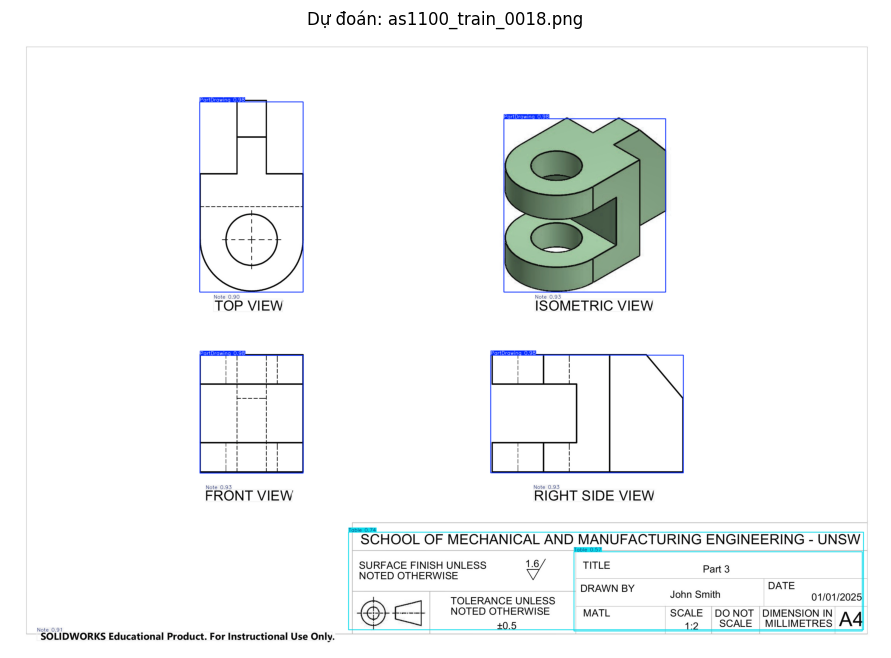

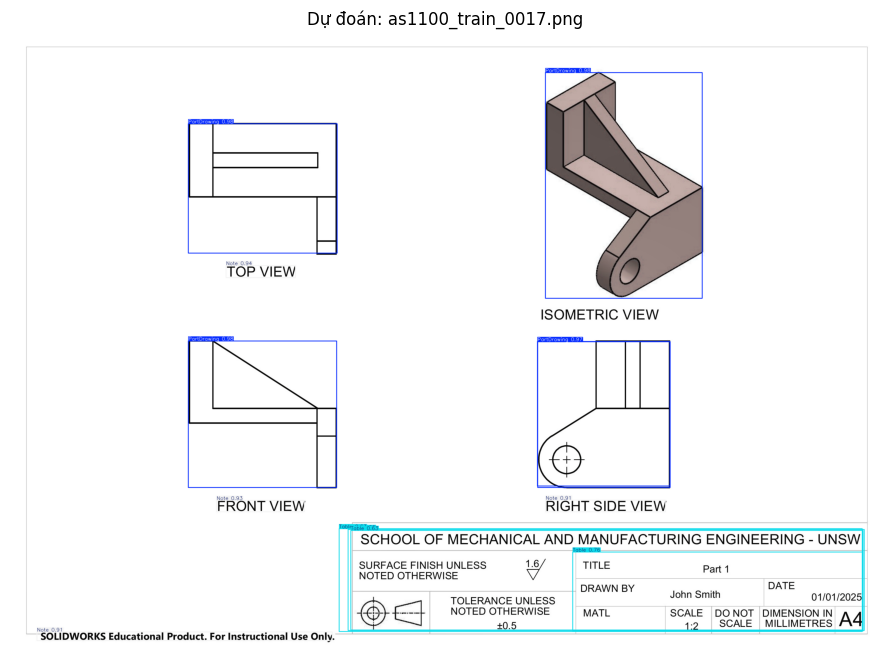

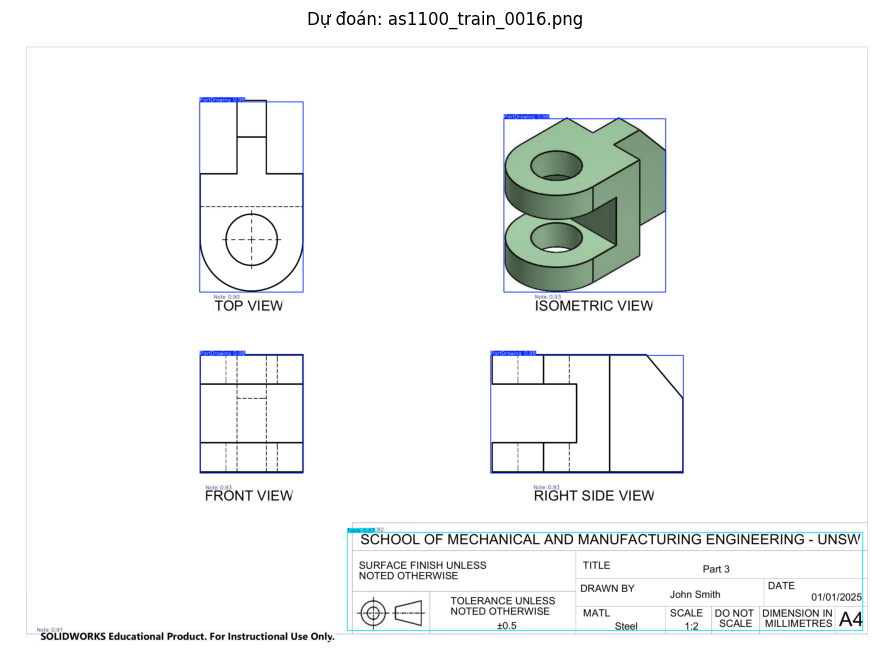

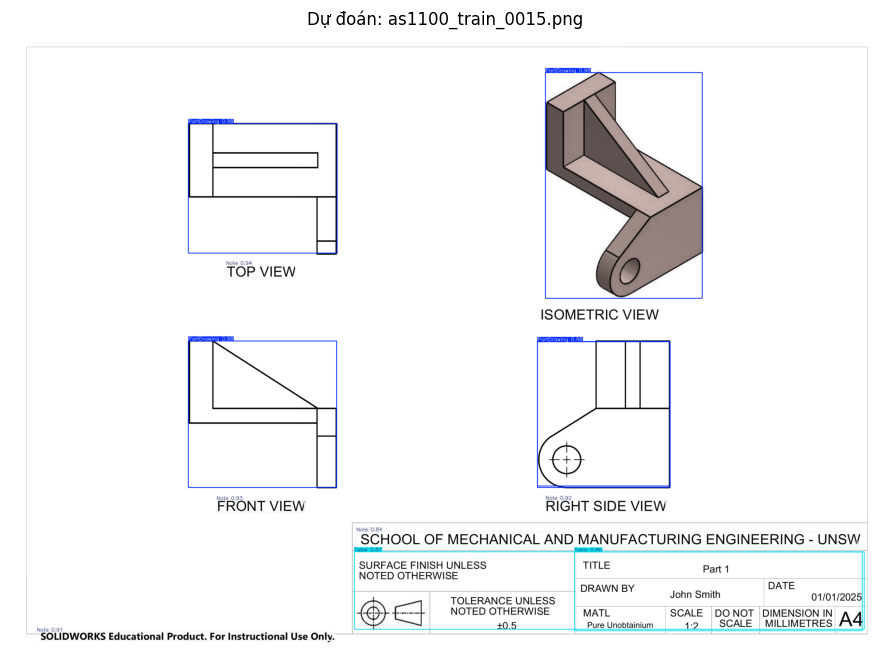

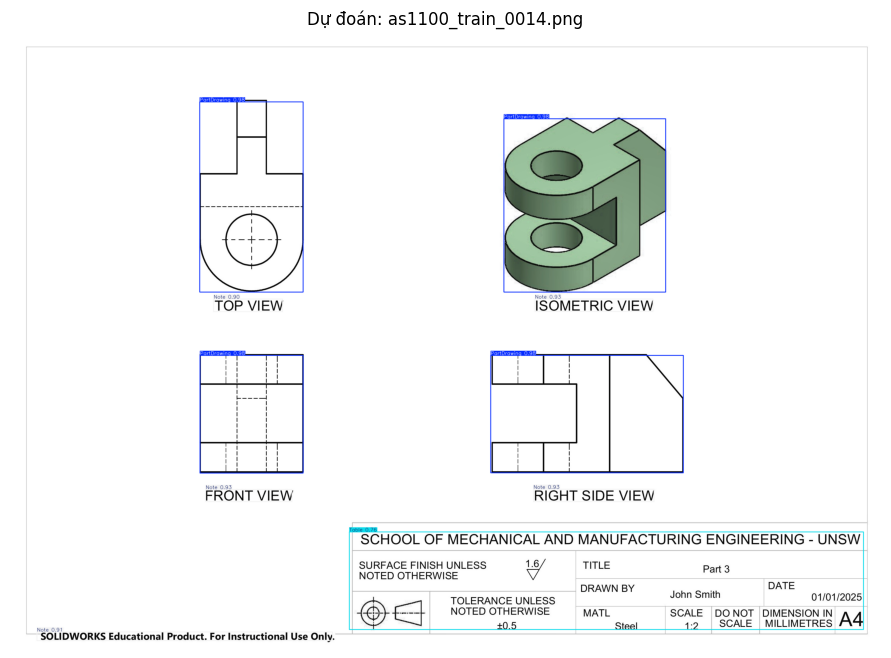

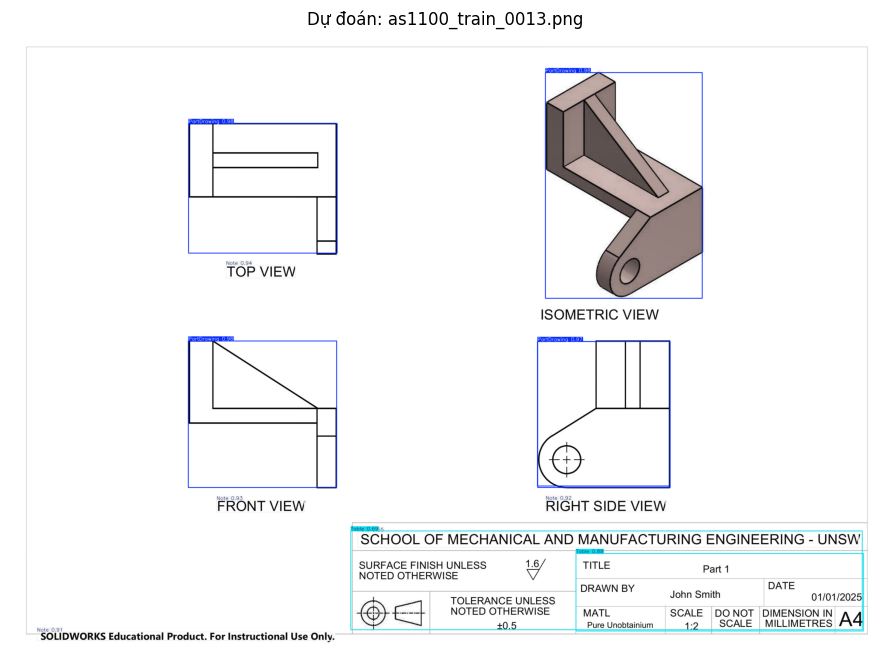

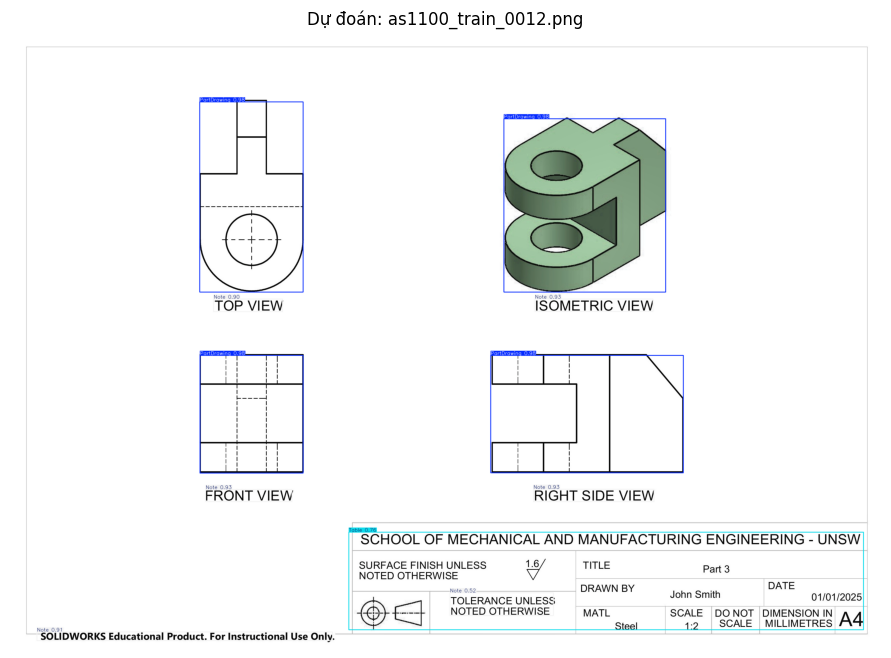

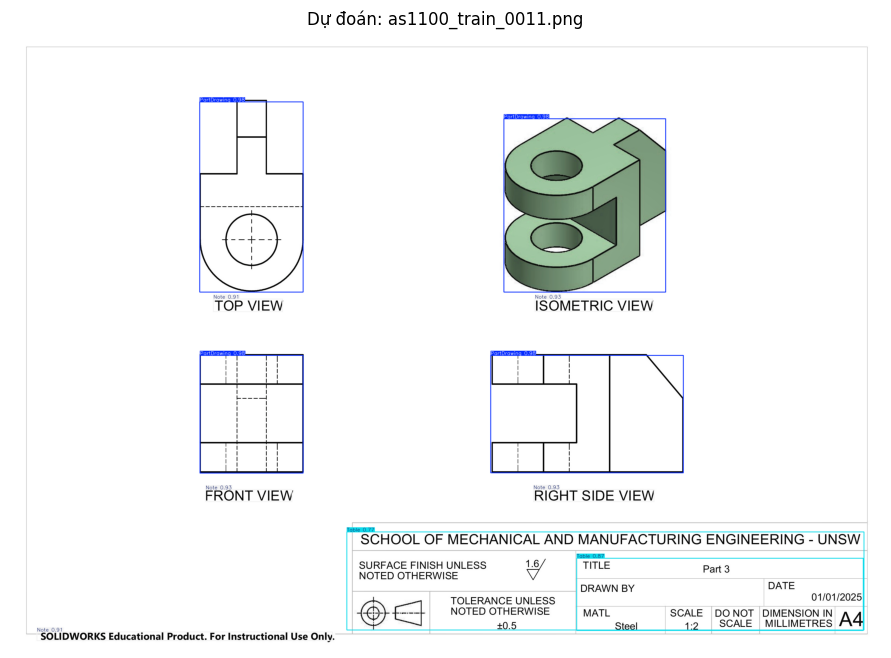

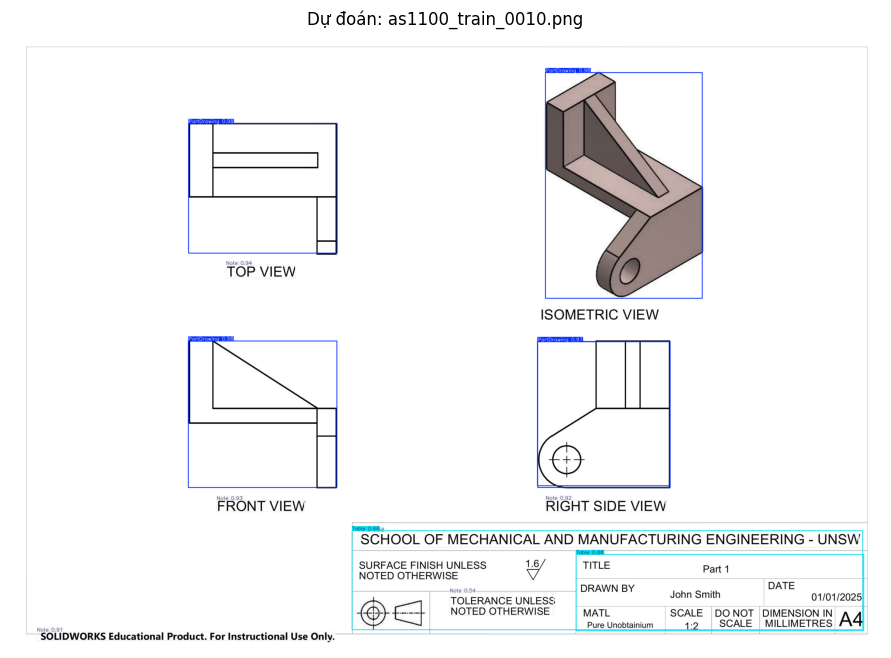

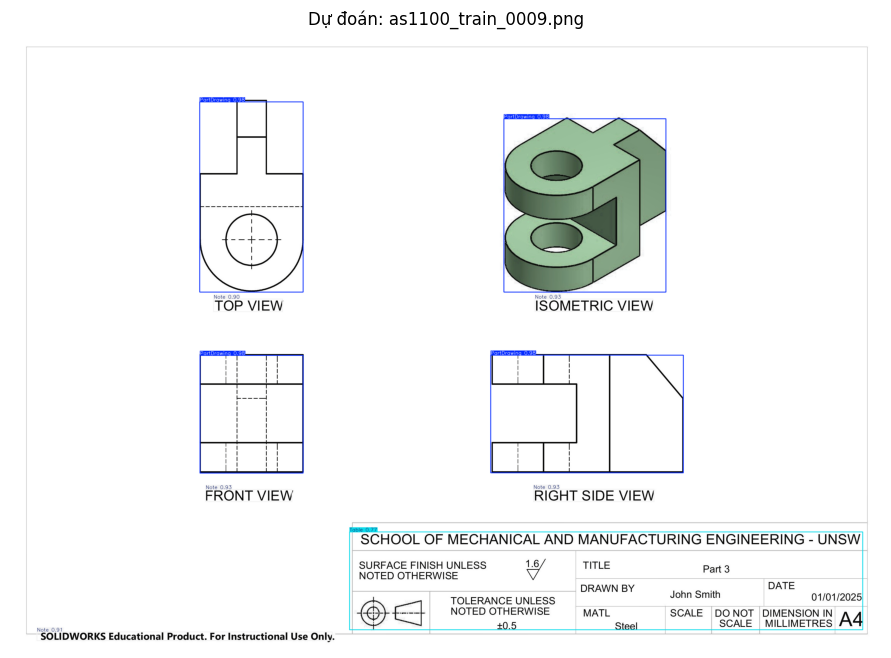

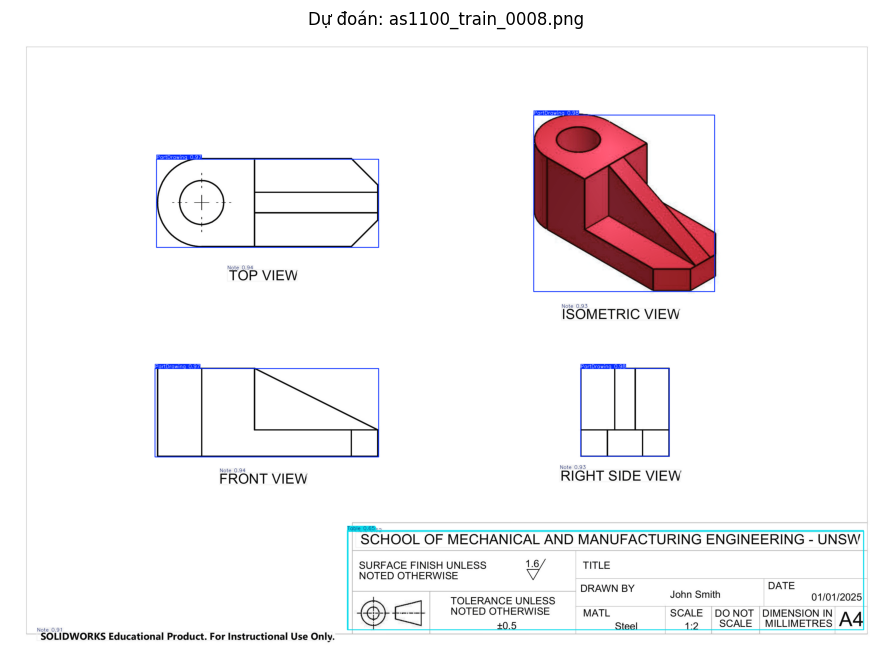

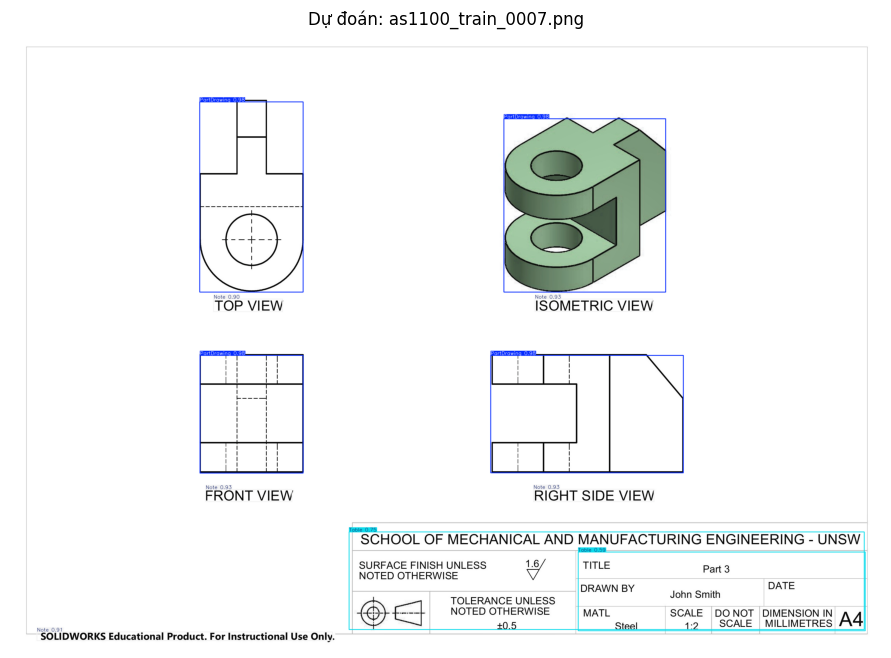

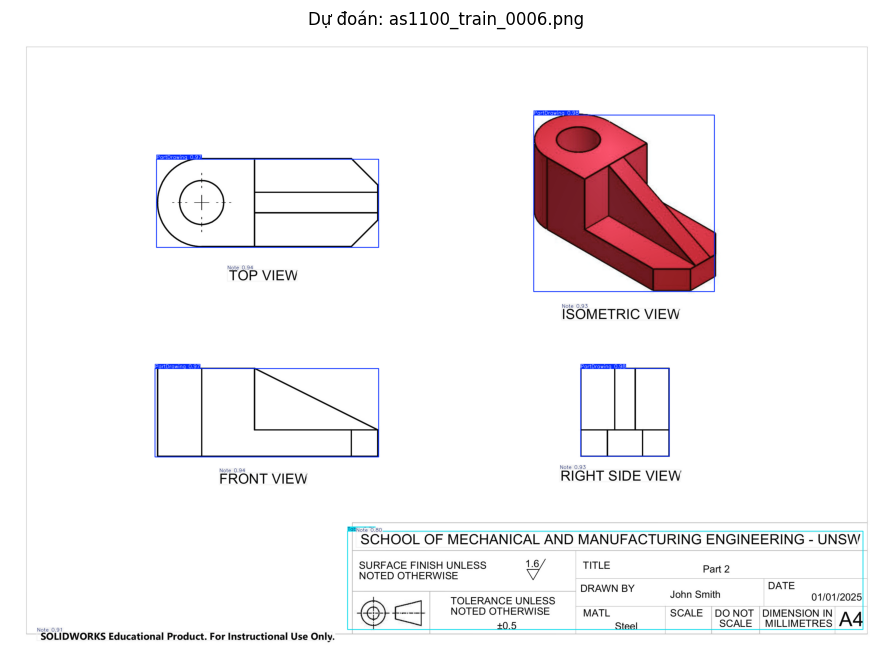

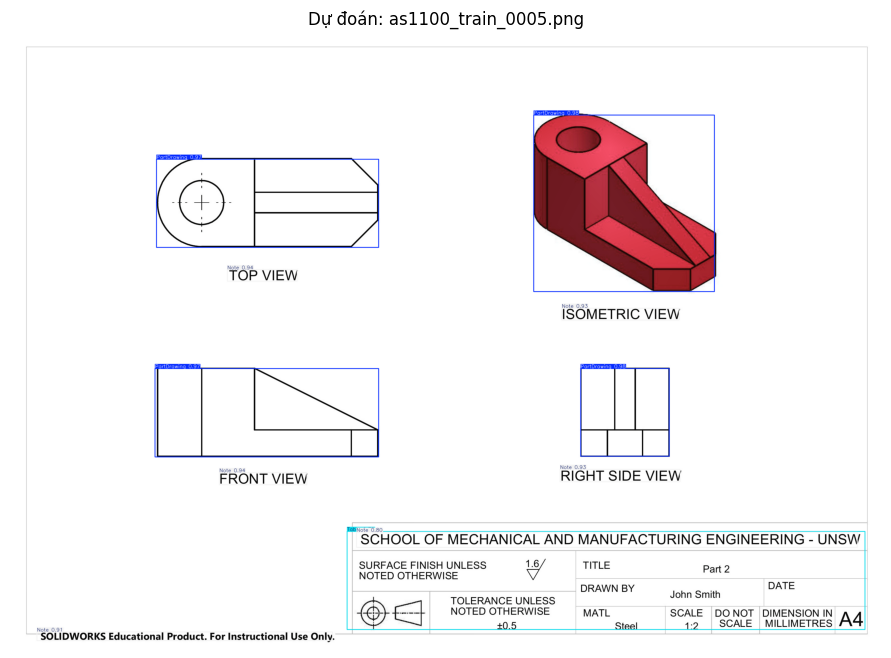

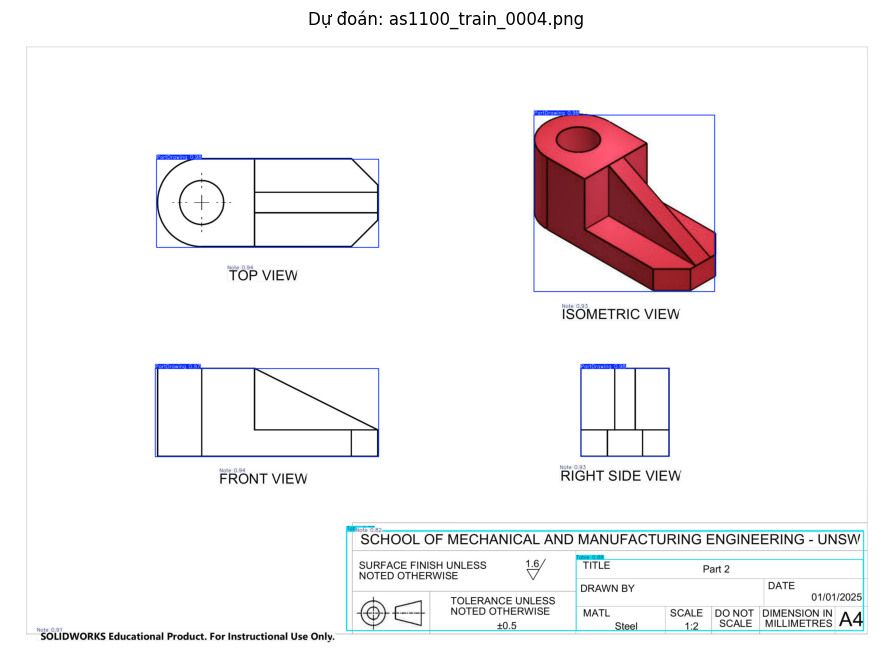

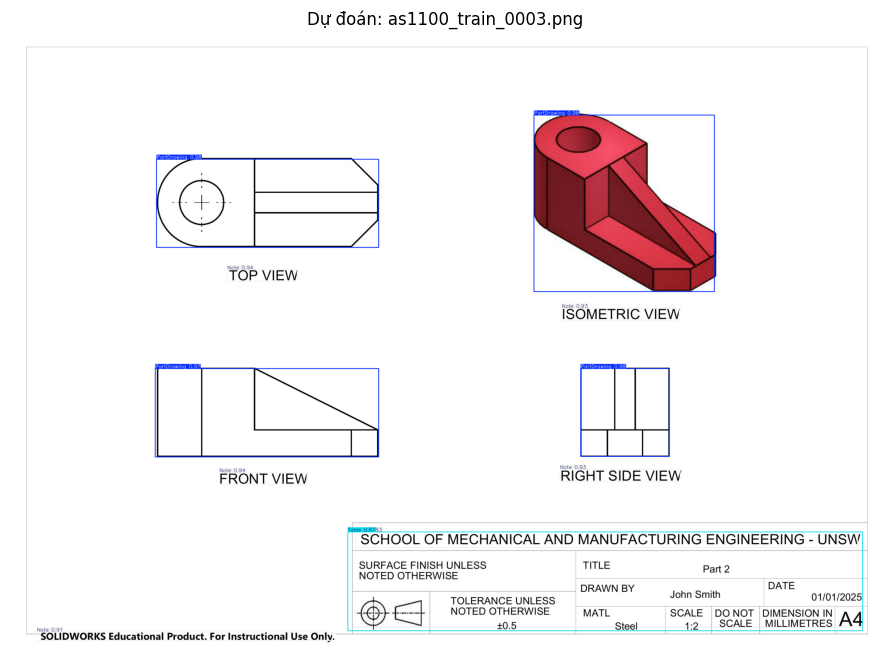

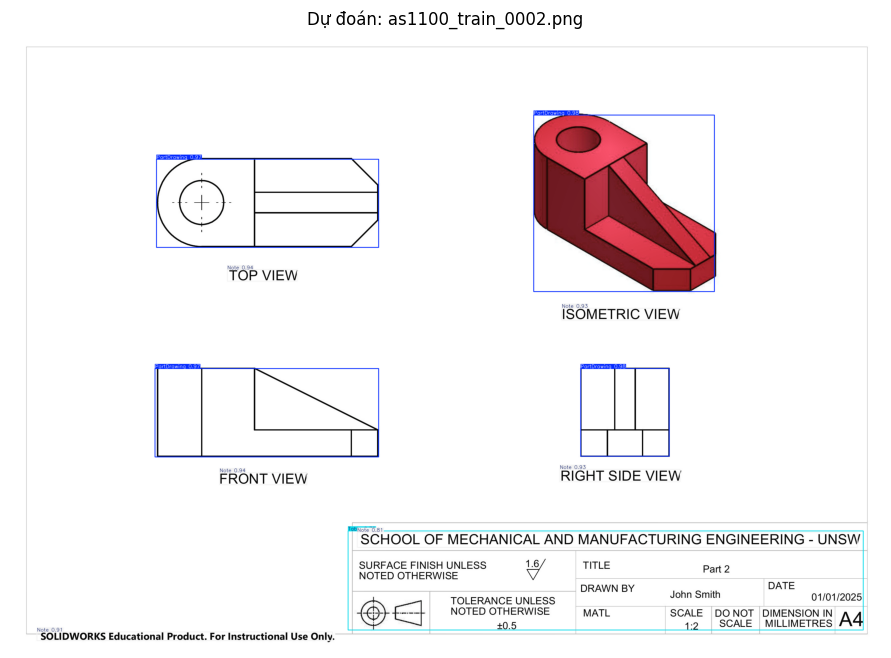

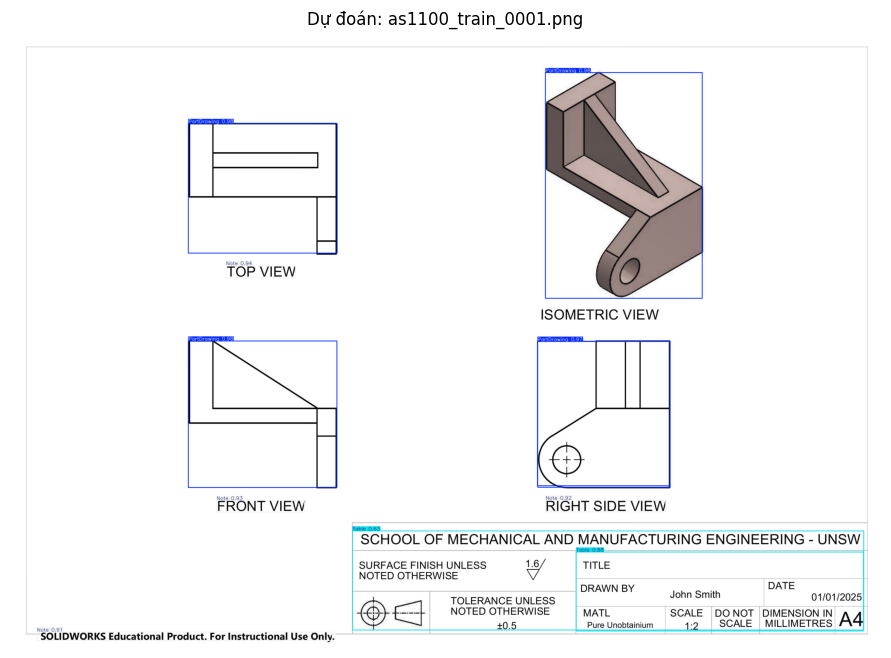

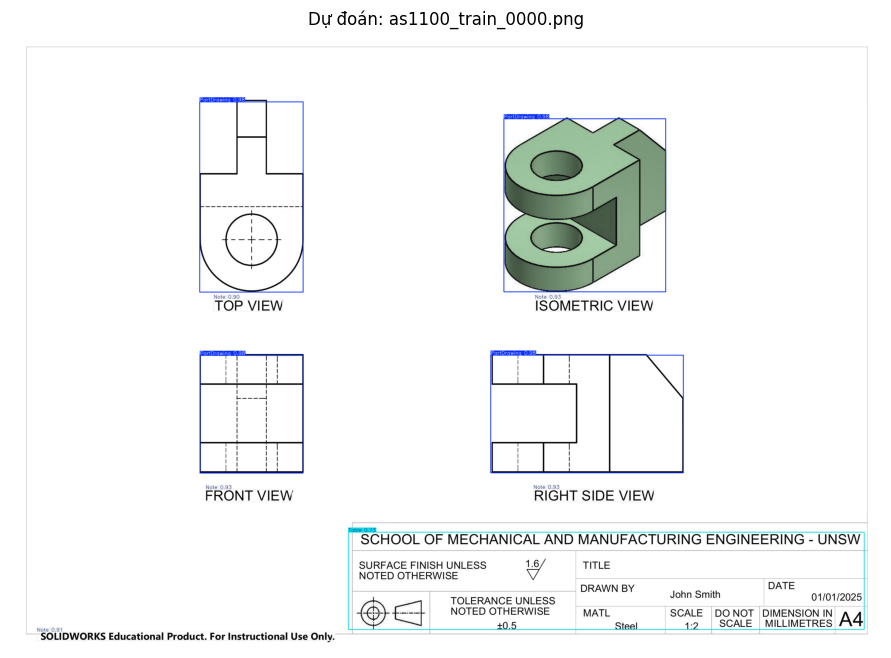

In [4]:
%matplotlib inline
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import RTDETR
import albumentations as A

# 1. Load model
model_path = "runs/detect/OD_OCR_Final/rtdetr_x_stable_run/weights/best.pt"
best_model = RTDETR(model_path)

# 2. Cấu hình CLAHE (Phải giống hệt lúc Train)
clahe_transform = A.Compose([
    A.CLAHE(clip_limit=(2.0, 4.0), tile_grid_size=(8, 8), p=1.0)
])

# 3. Đường dẫn thư mục ảnh Validation
val_images_path = "cvat_images_from_files/train"
image_files = [os.path.join(val_images_path, f) for f in os.listdir(val_images_path) if f.endswith(('.jpg', '.png'))]

print(f"Đang kiểm tra {len(image_files)} ảnh trong tập Validation...")

for img_path in image_files:
    # Đọc ảnh gốc
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue
    
    # Bước cực kỳ quan trọng: Áp dụng CLAHE trước khi dự đoán
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    augmented = clahe_transform(image=img_rgb)
    img_clahe = augmented['image']
    
    # Dự đoán trên ảnh đã qua CLAHE
    # stream=True giúp tiết kiệm RAM khi duyệt nhiều ảnh
    results = best_model.predict(source=img_clahe, conf=0.5, save=False, verbose=False)
    
    for r in results:
        # Vẽ Bounding Box lên ảnh (Lưu ý: r.plot trả về BGR)
        im_array = r.plot(labels=True, conf=True, line_width=2)
        im_rgb_plot = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)
        
        # Hiển thị bằng Matplotlib
        plt.figure(figsize=(12, 8))
        plt.imshow(im_rgb_plot)
        plt.title(f"Dự đoán: {os.path.basename(img_path)}")
        plt.axis('off')
        plt.show()